In [1]:
import matplotlib.pyplot as plt
import matplotlib
import math
from astropy.io import fits
import numpy as np
import pandas as pd 
# import cv2
import skimage as sk
import scipy.ndimage as nd
from functions_CONNIE import *

# from ROOT import *

def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean)**2 / (2 * sigma**2)))

# def Gaussian2(x,m1,s1,g1,a1, m2, s2, g2, a2): #data, mean, sigma, gain, height1, heigth2
#     return a1*np.exp(-1/2*((x-m1-g1)/s1)**2) + a2*np.exp(-1/2*((x-m2-g2)/s2)**2)

def Gaussian2(x,m,s,g,a1,a2): #data, mean, sigma, gain, height1, heigth2
    return a1*np.exp(-1/2*((x-m)/s)**2)+a2*np.exp(-1/2*((x-m-g)/s)**2)

In [2]:
plt.rcParams.update({
    "image.origin": "lower",
    "image.aspect": 1,
    #"text.usetex": True,
    "grid.alpha": .5,
    "axes.linewidth": 3,
    "lines.linewidth" : 1,
    "font.size":    15.0,
    "xaxis.labellocation": 'right',  # alignment of the xaxis label: {left, right, center}
    "yaxis.labellocation": 'top',  # alignment of the yaxis label: {bottom, top, center}
    "xtick.top":           True ,  # draw ticks on the top side
    "xtick.major.size":    8    ,# major tick size in points
    "xtick.minor.size":    4      ,# minor tick size in points
    "xtick.direction":     'in',
    "xtick.minor.visible": True,
    "ytick.right":           True ,  # draw ticks on the top side
    "ytick.major.size":    8    ,# major tick size in points
    "ytick.minor.size":    4      ,# minor tick size in points
    "ytick.direction":     'in',
    "ytick.minor.visible": True,
    "ytick.major.width":   2   , # major tick width in points
    "ytick.minor.width":   1 ,
    "xtick.major.width":   2   , # major tick width in points
    "xtick.minor.width":   1 ,
    "legend.framealpha": 0 ,
    "legend.loc": 'best',

})

Colormap = 'jet'
ColorMap = Colormap
Norm = mpl.colors.LogNorm(vmin=10**-1, vmax=7 * 10**0)

Filename: ../images/CONNIE/RUNID_116/cal_11_2_v2_proc_runID116_skp_NSAMP400_EXP0_img1_2525.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     173   (420, 1022)   float32   
None
----------------


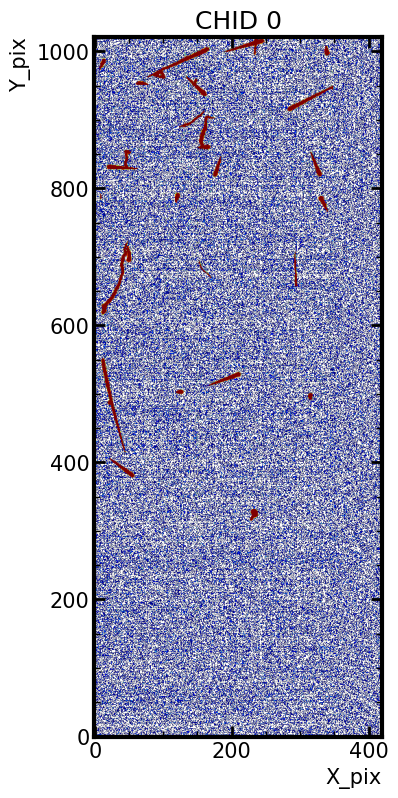

In [3]:
path = '../images/CONNIE/RUNID_116/cal_11_2_v2_proc_runID116_skp_NSAMP400_EXP0_img1_2525.fits'


hdu_list = fits.open(path)
print(hdu_list.info())
print('----------------')
hdu_list[0].header
plt.figure(figsize=(20,20))
# for i in range(4):
plt.subplot(2,2,1)
# plt.imshow(hdu_list[0].data-np.median(hdu_list[0].data),vmin=0,vmax=1, cmap = Colormap)
plt.imshow(hdu_list[0].data-np.median(hdu_list[0].data), cmap = Colormap, norm=Norm)
plt.title('CHID '+str(0))
plt.ylabel('Y_pix')
plt.xlabel('X_pix')
plt.show()

In [4]:
path.split('/')[-1].split('_')[-2].split('g')[-1]

'1'

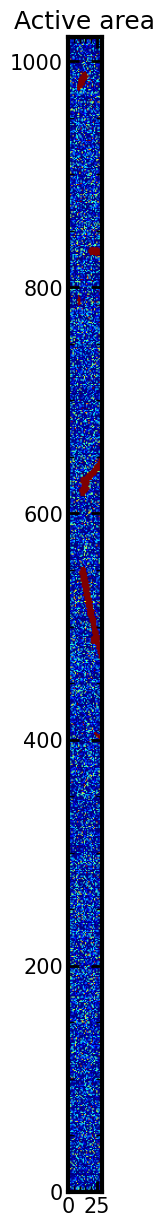

In [5]:
# Overscan = hdu_list[0].data[:, 350:]
# active_area = hdu_list[0].data[:600, :]
active_area = hdu_list[0].data[:, :]

header = hdu_list[0].header


fig, axs = plt.subplots(1,1, figsize=[10,15])
# oScan_mask=sk.measure.label(Overscan>=np.max(Overscan) , connectivity=2)
# oScan=ma.masked_array(Overscan,mask=(oScan_mask>0))
axs.imshow(active_area[:, :30], origin='lower', vmin = 0, vmax = 0.5,  cmap = Colormap)
# axs.imshow(active_area, origin='lower',  cmap = Colormap, norm = Norm)
axs.set_title('Active area')

# axs[1].imshow(Overscan, origin='lower', vmin = 0, vmax = 1)
# axs[1].set_title('OverScan')

# fig.colorbar()
# plt.show()

# fig, axs = plt.subplots(figsize=[10,10])
# active_area_mask=sk.measure.label(active_area>=np.max(active_area), connectivity=2)
# active_area_true=ma.masked_array(active_area,mask=(active_area_mask>0))
# plt.colorbar(location = 'bottom')
# plt.colorbar()

# fig.colorbar(x1, ax=axs[0])
# fig.colorbar(x2, ax=axs[1])

plt.show()


In [6]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  420                                                  
NAXIS2  =                 1022                                                  
CCDNCOL = '682     '           / Smart sequencer variable                       
CCDNPRES= '7       '           / Smart sequencer variable                       
CCDNROW = '1022    '           / Smart sequencer variable                       
EXPOSURE= '0       '           / Smart sequencer variable                       
NBINCOL = '1       '           / Smart sequencer variable                       
NBINROW = '1       '           / Smart sequencer variable                       
NCOL    = '420     '           / Smart sequencer variable                       
NROW    = '1022    '        

## Creación del DataFrame

In [7]:
sigma_eletrons = header['RD_NOISE']
min_energy_for_label = 5 * sigma_eletrons
label_img, nlabels_img = sk.measure.label(active_area > min_energy_for_label, connectivity=2, return_num=True)
prop = sk.measure.regionprops(label_img, active_area)

# plt.imshow(label_img == nlabels_img, vmin=0, vmax=1)
TotalDataFrame = event_DataFrame(dataCal=active_area, label_img=label_img, nlabels_img =nlabels_img, 
                                    prop=prop, header=header, extension=1, unidades = 2)

range_matrixsize = TotalDataFrame[TotalDataFrame['Event Size (px)'].between(50, 10000)]
range_energy = TotalDataFrame[TotalDataFrame['Total Charge (KeV)'].between(100, 300)]

display(range_energy[0:10])
display(range_matrixsize[0:50])

Events: 1699


,Image ID,Extension,Matrix Size (px),Event Size (px),Total Charge (KeV),Mean Charge (KeV),Barycenter (px)
Event ID,,,,,,,


,Image ID,Extension,Matrix Size (px),Event Size (px),Total Charge (KeV),Mean Charge (KeV),Barycenter (px)
Event ID,,,,,,,
217,2525,1,13x19,153,111159.859375,726.534973,"[5.7255, 9.7386]"
282,2525,1,37x29,223,66272.578125,297.186005,"[20.2825, 12.6682]"
338,2525,1,37x140,690,200598.687500,290.722992,"[14.6348, 79.1899]"
454,2525,1,7x11,62,30134.767578,486.045013,"[3.0806, 5.1452]"
461,2525,1,13x8,65,54134.050781,832.831970,"[6.2769, 3.4]"
478,2525,1,48x21,266,77907.429688,292.885010,"[27.0564, 10.0188]"
646,2525,1,45x108,761,283840.875000,372.984009,"[25.3548, 55.0539]"
714,2525,1,6x51,158,73519.882812,465.316010,"[2.4367, 22.4051]"
748,2525,1,19x26,73,52233.046875,715.520996,"[7.9041, 11.8219]"


## Visualizar un cluster y su información

19
Event Slice:
x: [152,171]
y: [670,696]


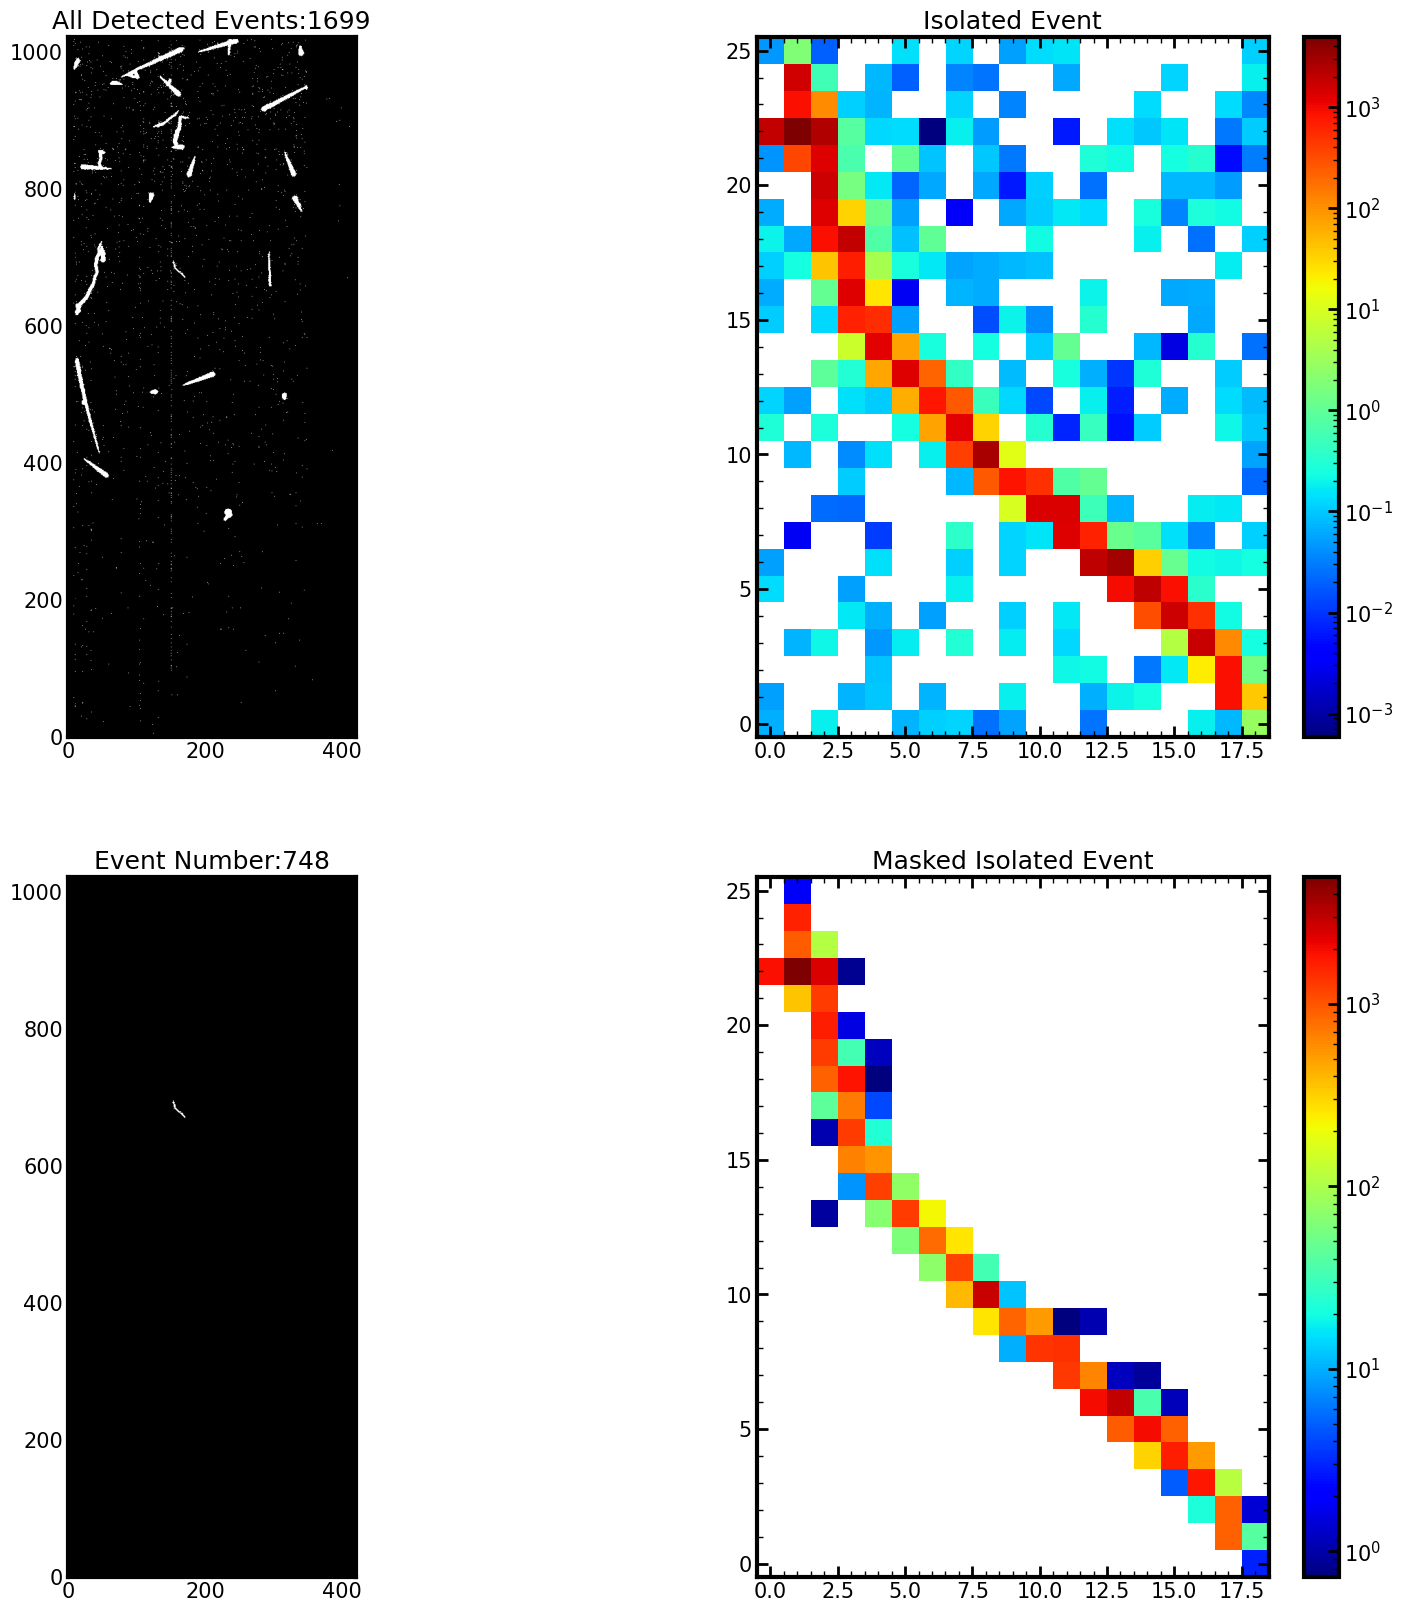

,Image ID,Extension,Matrix Size (px),Event Size (px),Total Charge (KeV),Mean Charge (KeV),Barycenter (px)
Event ID,,,,,,,
748,2525,1,19x26,73,52233.046875,715.520996,"[7.9041, 11.8219]"


In [10]:
n_label = 748 #461, 282
extra = 0


label, n_events = nd.label(active_area > min_energy_for_label,structure=[[1,1,1],[1,1,1],[1,1,1]]) # 48
# label, n_events = nd.label(dataCal>6*abs(popt[2]),structure=[[0,1,0],[1,1,1],[0,1,0]]) ## 50, 52
loc = nd.find_objects(label==n_label)[0]

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=[20,20])
# fig.subplots_adjust(left=0.1, bottom=0.1, right=0.5, top=0.9)
# fig.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9)

# fig.suptitle('Event Number '+ str(n_label))
## Imagen original
axs[0,0].set_title('All Detected Events:'+str(n_events))
axs[0,0].imshow(label==0, cmap='gist_yarg', vmax=1, vmin=0, origin='lower')
# plt.suptitle('Primer Imagen')

## Evento en la imagen original
axs[1,0].set_title('Event Number:'+str(n_label))
axs[1,0].imshow(label==n_label, cmap='gray', vmax=1,vmin=0, origin='lower')


axs[0,1].set_title('Isolated Event')
x1 = axs[0,1].imshow(active_area[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra], cmap= Colormap, norm=matplotlib.colors.LogNorm())#, origin = 'lower')
# plt.colorbar()

mask_35 = np.invert(label==n_label)


data_mask = ma.masked_array(active_area[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra], mask_35[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra])
print(len(data_mask[0]))

axs[1,1].set_title('Masked Isolated Event')
x2 = axs[1,1].imshow(data_mask, cmap= Colormap, norm=matplotlib.colors.LogNorm())#, origin='lower')
# axs[1,1].plot(totalFrame.iat[n_label-1, 7][0], totalFrame.iat[n_label-1, 7][1], 'ro') ## Plot the baricentrum
# print('n_label:', n_label)
# plt.legend('Baricentrum')

fig.colorbar(x1, ax=axs[0,1])
fig.colorbar(x2, ax=axs[1,1])
# fig.colorbar(axs[1,1], ax=[[x1,x2]], location = 'bottom', fraction = .1)

print('Event Slice:'  )
print('x: ['+str(loc[1].start)+','+str(loc[1].stop)+']')
print('y: ['+str(loc[0].start)+','+str(loc[0].stop)+']')
# print(loc)
# print(totalFrame.set_index('Event ID').iloc[[n_label-1]])
plt.show()


TotalDataFrame.iloc[[n_label-1]]

### Con faldas

5
Event Slice:
x: [158,159]
y: [102,103]


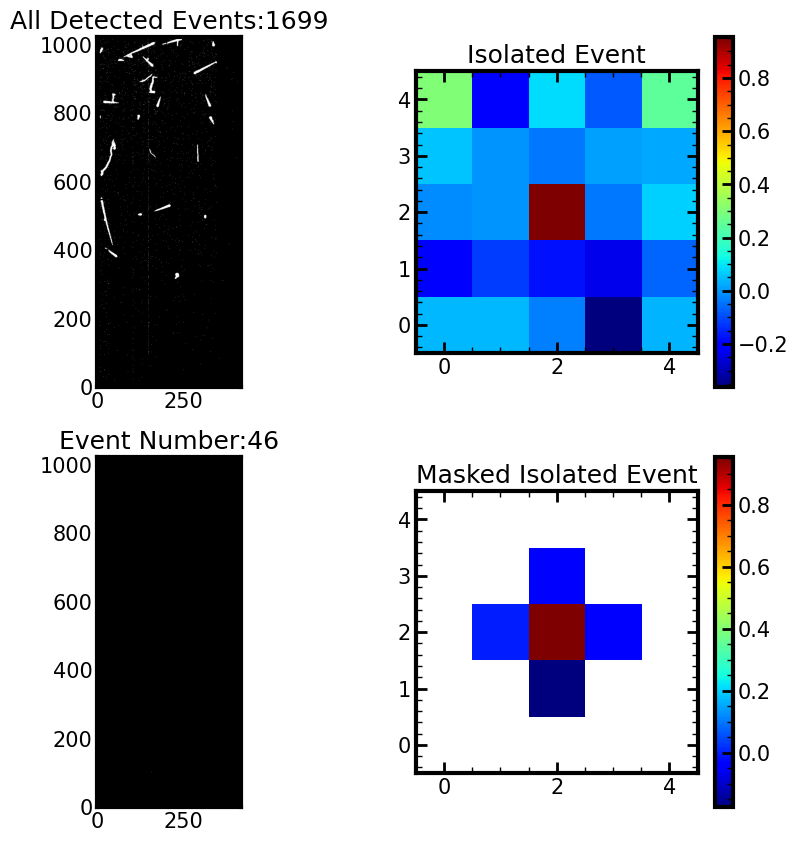

,Image ID,Extension,Matrix Size (px),Event Size (px),Total Charge (KeV),Mean Charge (KeV),Barycenter (px)
Event ID,,,,,,,
46,2525,1,1x1,1,0.953797,0.954,"[0.0, 0.0]"


In [13]:
n_label = 46
n_skirts = 1
extra = n_skirts + 1


label, n_events = nd.label(active_area > min_energy_for_label,structure=[[1,1,1],[1,1,1],[1,1,1]]) # 48
# label, n_events = nd.label(dataCal>6*abs(popt[2]),structure=[[0,1,0],[1,1,1],[0,1,0]]) ## 50, 52
loc = nd.find_objects(label==n_label)[0]

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=[10,10])
# fig.subplots_adjust(left=0.1, bottom=0.1, right=0.5, top=0.9)
# fig.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9)

# fig.suptitle('Event Number '+ str(n_label))
## Imagen original
axs[0,0].set_title('All Detected Events:'+str(n_events))
axs[0,0].imshow(label==0, cmap='gist_yarg', vmax=1, vmin=0, origin='lower')
# plt.suptitle('Primer Imagen')

## Evento en la imagen original
axs[1,0].set_title('Event Number:'+str(n_label))
axs[1,0].imshow(label==n_label, cmap='gray', vmax=1,vmin=0, origin='lower')


axs[0,1].set_title('Isolated Event')
x1 = axs[0,1].imshow(active_area[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra], cmap= ColorMap)#, origin = 'lower')
# plt.colorbar()

### Skirts ###
mask_35 = np.invert(nd.binary_dilation(label==n_label, iterations= n_skirts))
# mask_35 = np.invert(label==n_label)
# skirt = nd.binary_dilation(mask_35, structure=[[0,0,0],[0,1,0],[0,0,0]], iterations = 2)
# print(skirt)


data_mask = ma.masked_array(active_area[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra], mask_35[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra])
print(len(data_mask[0]))

axs[1,1].set_title('Masked Isolated Event')
x2 = axs[1,1].imshow(data_mask, cmap= ColorMap)#, origin='lower')
# axs[1,1].plot(totalFrame.iat[n_label-1, 7][0], totalFrame.iat[n_label-1, 7][1], 'ro') ## Plot the baricentrum
# print('n_label:', n_label)
# plt.legend('Baricentrum')

fig.colorbar(x1, ax=axs[0,1])
fig.colorbar(x2, ax=axs[1,1])
# fig.colorbar(axs[1,1], ax=[[x1,x2]], location = 'bottom', fraction = .1)

print('Event Slice:'  )
print('x: ['+str(loc[1].start)+','+str(loc[1].stop)+']')
print('y: ['+str(loc[0].start)+','+str(loc[0].stop)+']')
# print(loc)
# print(totalFrame.set_index('Event ID').iloc[[n_label-1]])
plt.show()


TotalDataFrame.iloc[[n_label-1]]

## Pruebas de la paquetería Sckit-Image

Centroide:  (np.float64(390.6681614349776), np.float64(43.28251121076233))
Radio mayor:  47.110968192282634
Radio menor:  6.600200629979374
Ellipticity: 0.8599009767101206
Box:  (378, 23, 407, 60)
Centroid Weighted:  (np.float64(393.89094119069995), np.float64(38.89283539840166))
Label:  282
Orientation:  -0.9298111077799515
Slice:  (slice(378, 407, None), slice(23, 60, None))
Eccentricity:  0.9901374973574235
Solidity:  0.8079710144927537
Barycenter:  [12.66816143 20.28251121]


Event Charge:  66272.58  keV
Local Box:  [37, 29]  px
Local Box:  [555, 435] micras
Diagonal Lenght:  45.596423531799545  px
Diagonal Lenght:  683.9463529769931  micras
Delta_L:  676.5382722646896  px
Delta_L:  10148.074083970343  micras
Delta EL:  97.95835777797866  keV/px
Delta EL:  6.530557185198577  keV/micras
Delta EL:  979583.5777797865  keV/cm


/tmp/ipykernel_5582/2828881388.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


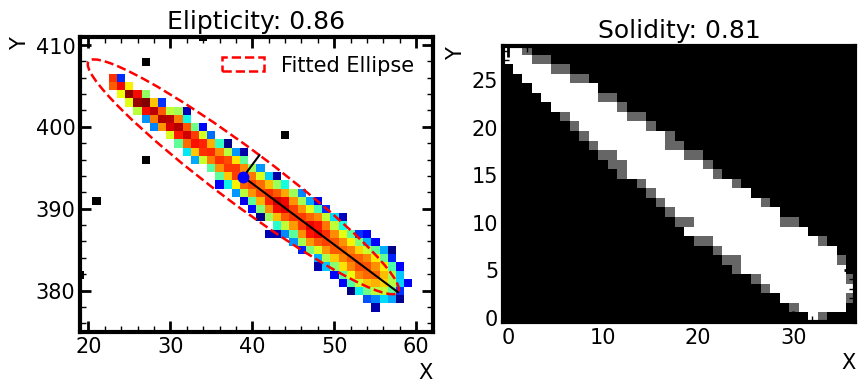

In [16]:
### Esta celda tiene el proceso para ir obteniendo las propiedadesd de un evento con la librería Scikit-Image
dataCal = active_area
extra = 4
ext = extra

import matplotlib.patches as patches
from skimage.morphology import convex_hull_object

n_label= 282 #282, 461, 646, 748
CCD_depth = 675 ## micras
px_to_micras = 15 ## micras
px_to_cm = 0.0015 ## cm/px
micra_to_cm = 1 / 10000 ## micras/cm
fig, ax = plt.subplots(1,2, figsize=(10,10))

label_img, nlabels_img = sk.measure.label(dataCal > min_energy_for_label, connectivity=2, return_num=True)
# print(nlabels_img)
ax[0].imshow(label==0, cmap='grey', vmax=1, vmin=0, origin='lower') # Matriz centrada en el origen

prop = sk.measure.regionprops(label_img,intensity_image=dataCal)
# prop = sk.measure.regionprops(label_img)

# loc = nd.find_objects(label==n_label)[0]
loc = prop[n_label-1].slice

mask_35 = np.invert(label_img==n_label)
# ax.imshow(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])

data_mask = ma.masked_array(dataCal[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra], mask_35[loc[0].start-extra:loc[0].stop+extra, loc[1].start-extra:loc[1].stop+extra])
data_mask_all = ma.masked_array(dataCal, mask_35)
ax[0].imshow(data_mask_all, norm=matplotlib.colors.LogNorm(), cmap = "jet")


hull_mask = convex_hull_object(data_mask)
# print(hull_mask)
contours = sk.measure.find_contours(hull_mask, level=0.0)
# if contours:
# find_contours returns (row, col) -> (y, x), so we flip it to (x, y) for Matplotlib
hull_vertices = contours[0][:, ::-1] 

# Create a visual polygon patch
polygon = patches.Polygon(
    hull_vertices, 
    closed=True, 
    edgecolor='black', 
    facecolor='gray', 
    alpha=0.6, # Slight shading inside the hull
    lw=1.5, 
    linestyle='--',
    label = "Convex Area"
)
# ax[1].add_patch(polygon)
# ax[1].imshow(data_mask, cmap= Colormap, norm=matplotlib.colors.LogNorm())

# for cluster in prop:
# Extract the binary mask of the object
actual_area =  prop[n_label-1].image

# Extract the binary mask of its convex hull
convex_area =  prop[n_label-1].convex_image
    
# Isolate the cavities (the grey regions in your diagram)
cavities = convex_area & ~actual_area
    
    # Create an RGB image to visualize the overlay
# White = Actual, Grey = Cavity, Black = Background
visualization = actual_area.astype(float) + (cavities.astype(float) * 0.4)
    
ax[1].imshow(visualization, cmap='gray', vmin=0, vmax=1)
# plt.title(f"solidity = { prop[n_label-1].solidity:.2f}")
# plt.axis('off')
# plt.show()

hull_overlay = np.where(hull_mask, 1.0, np.nan)

# Plot your original muon cluster first
# ax.imshow(dataCal, cmap='viridis', origin='lower')

# Overlay the convex hull envelope as a translucent red/white shade
# ax[1].imshow(hull_overlay, cmap='grey', alpha=0.5, origin='lower')

charge = data_mask.sum()
# plt.imshow(dataCal[maxim.start:maxim.stop])
# ax.imshow(data_mask)

Maxis = prop[n_label-1].axis_major_length
maxis = prop[n_label-1].axis_minor_length
elip = (Maxis - maxis)/Maxis
sol = prop[n_label-1].solidity

print("Centroide: ", prop[n_label-1].centroid)
print("Radio mayor: ", Maxis)
print("Radio menor: ", maxis)
print(f"Ellipticity: {elip}")
print("Box: ", prop[n_label-1].bbox)
# print("Centroide Local: ", prop[n_label-1].centroid_local)
print('Centroid Weighted: ', prop[n_label-1].centroid_weighted)
# print(prop[n_label-1].centroid_weighted_local)
# print(prop[n_label-1].coords_scaled)
# print(prop[n_label-1].coords)
# print(prop[n_label-1].extent)
# print(prop[n_label-1].image)
# print(prop[n_label-1].image_intensity)
print('Label: ', prop[n_label-1].label)
print('Orientation: ', prop[n_label-1].orientation)
print('Slice: ', prop[n_label-1].slice)
print('Eccentricity: ', prop[n_label-1].eccentricity)
print('Solidity: ', sol)
print('Barycenter: ', prop[n_label-1].centroid_local)
# print('Inertia tensor: ', prop[n_label-1].inertia_tensor)
# print('Intensity Max: ', prop[n_label-1].intensity_max)

print('\n')
## Ellipse 
# y0, x0 = prop[n_label-1].centroid
y0, x0 = prop[n_label-1].weighted_centroid
# y0, x0 = prop[n_label-1].centroid_weighted

orientation = prop[n_label-1].orientation
rotation = orientation*1
x1 = x0 + math.cos(orientation) * 0.5 * prop[n_label-1].axis_minor_length
y1 = y0 - math.sin(orientation) * 0.5 * prop[n_label-1].axis_minor_length

x2 = x0 - math.sin(orientation) * 0.5 * prop[n_label-1].axis_major_length
y2 = y0 - math.cos(orientation) * 0.5 * prop[n_label-1].axis_major_length # Ellipse's major radio

x3 = x0 - math.sin(-orientation) * 0.5 * prop[n_label-1].axis_major_length
y3 = y0 + math.cos(orientation) * 0.5 * prop[n_label-1].axis_major_length # Ellipse's major radio


ax[0].plot((x0, x1), (y0, y1), 'k', linewidth=1.5)
# ax[0].plot((x0, y1), (y0, -x1), 'g', linewidth=1)
# ax[0].plot((x0, x3), (y0, y3), 'k', linewidth=1.5)
ax[0].plot((x0, x2), (y0, y2), 'k', linewidth=1.5)

ax[0].plot(x0, y0, '.b', markersize=15) # Ellipse's center

ellipAngle = angle_deg = np.rad2deg(-orientation) + 90
ellip = patches.Ellipse(
    xy=(x0, y0), 
    width=Maxis, 
    height=maxis, 
    angle=(ellipAngle), 
    edgecolor = "red", 
    facecolor = 'none', 
    lw =1.8,
    linestyle='--',
    label = "Fitted Ellipse"
    # label = "Elipse Ajustado"
)
# ax.plot(prop[n_label-1].centroid_weighted[1], prop[n_label-1].centroid_weighted[0], '.g', markersize=15)
ax[0].add_patch(ellip)

## Box and Delta_L
miny, minx, maxy, maxx = prop[n_label-1].bbox
Longitud_y = maxy - miny # px
Longitud_x = maxx - minx # px
Diagonal_lenght= np.sqrt(Longitud_x**2 + Longitud_y**2) - np.sqrt(2) # px
Delta_L = np.sqrt(Diagonal_lenght**2 + CCD_depth**2) # px
DeltaEL = charge / Delta_L # keV/px

print('Event Charge: ', charge, ' keV')
print("Local Box: ", [Longitud_x, Longitud_y], ' px' )
print("Local Box: ", [Longitud_x * px_to_micras, Longitud_y * px_to_micras], 'micras' )
print('Diagonal Lenght: ', Diagonal_lenght, ' px') ## px
print('Diagonal Lenght: ', Diagonal_lenght * px_to_micras, ' micras')
print('Delta_L: ', Delta_L, ' px')
print('Delta_L: ', Delta_L * px_to_micras, ' micras')
print('Delta EL: ', DeltaEL, ' keV/px')
print('Delta EL: ', DeltaEL / px_to_micras, ' keV/micras')
print('Delta EL: ', DeltaEL / micra_to_cm, ' keV/cm')
bx = (minx, maxx, maxx, minx, minx)
by = (miny, miny, maxy, maxy, miny)
# ax.plot(bx, by, '-b', linewidth=2.5)


# excent = prop[n_label-1].eccentricity
u= x0   #x-position of the center
v= y0    #y-position of the center
b = prop[n_label-1].axis_major_length    #radius on the x-axis
a = prop[n_label-1].axis_minor_length   #radius on the y-axis

ext=1
ax[0].axis((minx-extra, maxx+extra-2, miny-extra+1, maxy+extra))
# ax.imshow(data_mask)
# ax.can_zoom()

# ax[0].set_title(f"Elipticidad: {round(elip, 2)}")
ax[0].set_title(f"Elipticity: {round(elip, 2)}")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")
# ax[1].axis("off")
ax[1].set_title(f"Solidity: {round(sol,2)}")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")

ax[0].legend()
ax[1].legend()
plt.show()
# print(loc[1].start-extra, loc[1].stop+extra, loc[0].start-extra, loc[0].stop+extra)

## Filtro de muones 

In [17]:
## Calcula cuantos eventos rectos tiene la extensión comparando la relación del radio mayor de la elipse con el radio menor

dict_lists = muon_filter(dataCal=dataCal, label_img=label_img, nlabels_img=nlabels_img, prop=prop, Solidit=0.65, Elipticity=0.65, dedl_min = 0, CCD_depth=0.675)
DeltaL = dict_lists["muons"]["l"]
DeltaEL = dict_lists["muons"]["dedl"]
list_charge = dict_lists["muons"]["charge_muons"]
list_theta = dict_lists["muons"]["theta"]
list_phi = dict_lists["muons"]["phi"]
list_elip = dict_lists["muons"]["elip"]
list_soli = dict_lists["muons"]["sol"]
list_datamasked = dict_lists["muons"]["image"]
lebel_muons = dict_lists["muons"]["label"]

list_charge_all_events = dict_lists["non_muons"]["charge"]
list_elip_all = dict_lists["non_muons"]["elip"]
list_sol_all = dict_lists["non_muons"]["sol"]
                                                                    
print('All Clusters: ', nlabels_img)
print('Muons Detected: ', len(lebel_muons))
print(lebel_muons)
Straight_Events = lebel_muons


DF_straightevents = pd.DataFrame(lebel_muons, columns=['Event ID'] )
DF_dl = pd.DataFrame(DeltaL, columns=['Delta L (cm)'])
DF_charge = pd.DataFrame(list_charge, columns=['Charge (KeV)'])
DF_dedl = pd.DataFrame(DeltaEL, columns=['dE/dL (KeV/cm)'])
DF_thet = pd.DataFrame(list_theta, columns=['Theta (Rad)'])
DF_phi = pd.DataFrame(list_phi, columns=['Phi (Rad)'])
DF_elip = pd.DataFrame(list_elip, columns=['Elipticity'])
DF_soli = pd.DataFrame(list_soli, columns=['Solidity'])
DF_dEdL = pd.concat([DF_straightevents, DF_dl, DF_charge,  DF_dedl, DF_thet, DF_phi, DF_elip, DF_soli], axis=1)
DF_dEdL.set_index('Event ID')

All Clusters:  1699
Muons Detected:  7
[282, 478, 714, 1065, 1071, 1356, 1486]


,Delta L (cm),Charge (KeV),dE/dL (KeV/cm),Theta (Rad),Phi (Rad),Elipticity,Solidity
Event ID,,,,,,,
282,0.068395,66272.578125,9.689729e+05,1.569809,5.648072,0.859901,0.807971
478,0.076468,77907.429688,1.018826e+06,1.569914,0.352576,0.872476,0.823529
714,0.074906,73519.882812,9.814913e+05,1.569895,4.742617,0.930609,0.661088
1065,0.048302,55430.253906,1.147578e+06,1.569399,4.409378,0.793128,0.820896
1071,0.058938,62136.378906,1.054265e+06,1.569651,5.098726,0.830344,0.727599
1356,0.116767,112465.234375,9.631569e+05,1.570218,3.608787,0.916807,0.686688
1486,0.027766,144203.812500,5.193530e+06,1.568365,3.008680,0.662971,0.966292


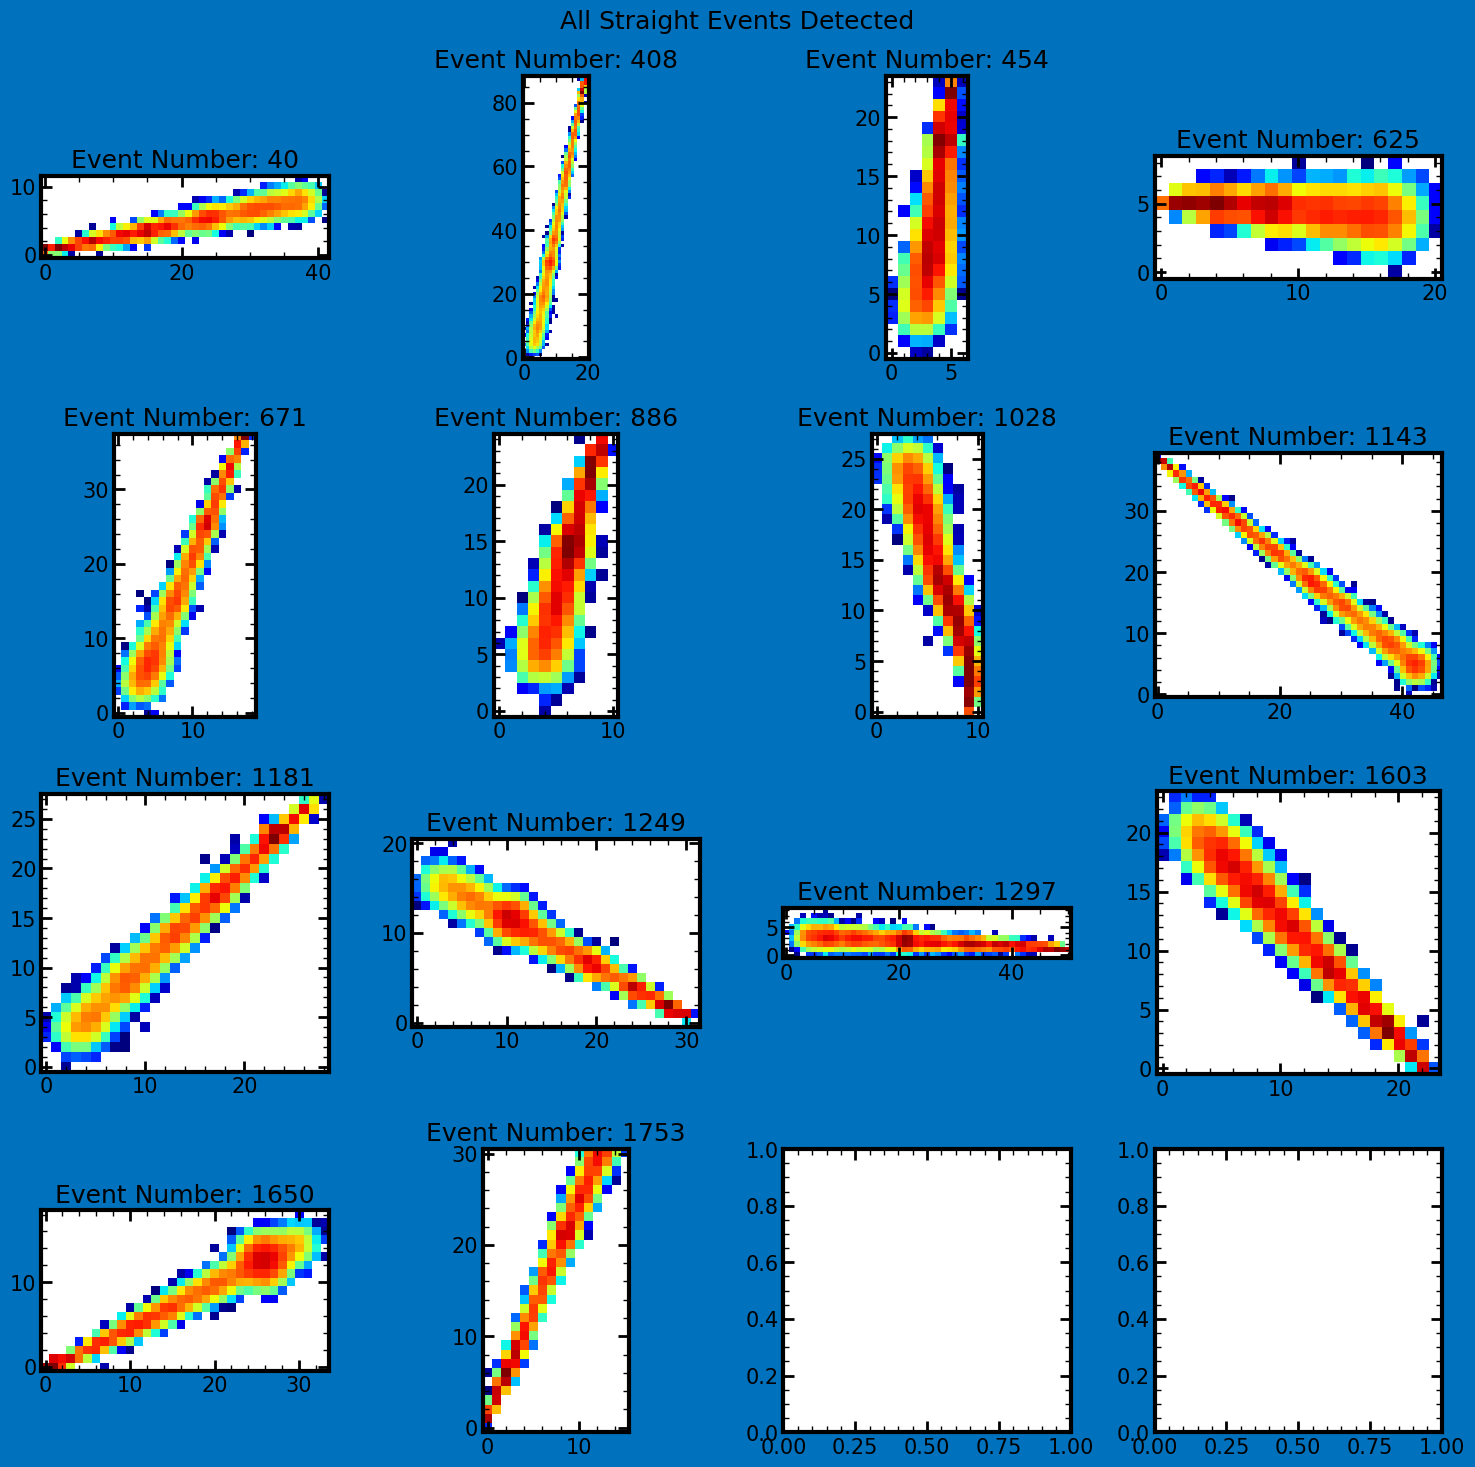

In [29]:
## Visualizar en una matriz los eventos rectos detectados 
coord2x2 = [[0,0],[0,1], [1,0], [1,1]]

coord3x3 = [[0,0],[0,1], [0,2], [1,0], [1,1], [1,2], [2,0], [2,1], [2,2]]

coord4x4 = [[0,0],[0,1], [0,2], [0,3], [1,0], [1,1], [1,2], [1,3], [2,0], [2,1], [2,2], [2,3], [3,0], [3,1], [3,2], [3,3]]

coords5x5 = [[0,0],[0,1], [0,2], [0,3], [0,4], [1,0], [1,1], [1,2], [1,3], [1,4], [2,0], [2,1], [2,2], [2,3], [2,4], [3,0], [3,1], [3,2], [3,3], [3,4],[4,0], [4,1], [4,2], [4,3], [4,4]]

if len(Straight_Events) < 5:
    fig, axs = plt.subplots(ncols = 2, nrows = 2, figsize=(15,15))
    fig.suptitle('All Muons Detected')

    for index_event in range(0,len(Straight_Events)):
        loc = nd.find_objects(label_img == Straight_Events[index_event])[0]
        mask_35 = np.invert(label_img == Straight_Events[index_event])
        data_mask = ma.masked_array(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_35[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])
        # plt.imshow(dataCal[maxim.start:maxim.stop])
        # ax.imshow(data_mask)

        axs[coord2x2[index_event][0],coord2x2[index_event][1]].set_title('Event Number: '+ str(Straight_Events[index_event]))
        # axs[coord2x2[index_event][0],coord2x2[index_event][1]].imshow(label_img == Straight_Events[index_event]) ## All image
        # axs[coord2x2[index_event][0],coord2x2[index_event][1]].imshow(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop]) ## Event without mask
        axs[coord2x2[index_event][0],coord2x2[index_event][1]].imshow(data_mask, cmap = ColorMap,  norm=matplotlib.colors.LogNorm()) ## Event with mask
        # axs[coord2x2[index_event][0],coord2x2[index_event][1]].plot(TF.iat[Straight_Events[index_event]-1, 9][0], TF.iat[Straight_Events[index_event]-1, 9][1],  'ro')#[0], TF.iat[index_


elif len(Straight_Events) > 4 and len(Straight_Events) < 10:
    fig, axs = plt.subplots(ncols = 3, nrows = 3, figsize=(15,15), facecolor = [0, 0.4470, 0.7410])
    fig.suptitle('All Straight Events Detected')

    for index_event in range(0,len(Straight_Events)):
        loc = nd.find_objects(label_img == Straight_Events[index_event])[0]
        mask_35 = np.invert(label_img == Straight_Events[index_event])
        data_mask = ma.masked_array(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_35[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])
        # plt.imshow(dataCal[maxim.start:maxim.stop])
        # ax.imshow(data_mask)

        axs[coord3x3[index_event][0],coord3x3[index_event][1]].set_title('Event Number: '+ str(Straight_Events[index_event]))
        # axs[coord3x3[index_event][0],coord3x3[index_event][1]].imshow(label_img == Straight_Events[index_event]) ## All image
        # axs[coord3x3[index_event][0],coord3x3[index_event][1]].imshow(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop]) ## Event without mask
        axs[coord3x3[index_event][0],coord3x3[index_event][1]].imshow(data_mask, aspect = 1, cmap = ColorMap,  norm=matplotlib.colors.LogNorm()) ## Event with mask
        # axs[coord3x3[index_event][0],coord3x3[index_event][1]].plot(TF.iat[Straight_Events[index_event]-1, 9][0], TF.iat[Straight_Events[index_event]-1, 9][1],  'ro')#[0], TF.iat[index_event, 7][1], 'ro') ## Plot the baricentrum

elif len(Straight_Events) > 9 and len(Straight_Events) < 17:
    fig, axs = plt.subplots(ncols = 4, nrows = 4, figsize=(15,15), facecolor = [0, 0.4470, 0.7410])
    fig.suptitle('All Straight Events Detected')

    for index_event in range(0,len(Straight_Events)):
        loc = nd.find_objects(label_img == Straight_Events[index_event])[0]
        mask_35 = np.invert(label_img == Straight_Events[index_event])
        data_mask = ma.masked_array(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_35[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])

        # coordX_centerCharge = round(nd.center_of_mass(data_maskEvent)[1])
        # coordY_centerCharge = round(nd.center_of_mass(data_maskEvent)[0])
        # Barycentercharge = data_maskEvent[coordY_centerCharge, coordX_centerCharge]

        axs[coord4x4[index_event][0],coord4x4[index_event][1]].set_title('Event Number: '+ str(Straight_Events[index_event]))
        # axs[coord4x4[index_event][0],coord4x4[index_event][1]].imshow(label_img == Straight_Events[index_event]) ## All image
        # axs[coord4x4[index_event][0],coord4x4[index_event][1]].imshow(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop]) ## Event without mask
        x2 = axs[coord4x4[index_event][0],coord4x4[index_event][1]].imshow(data_mask, aspect = 1, cmap = ColorMap,  norm=matplotlib.colors.LogNorm()) ## Event with mask
        # axs[coord4x4[index_event][0],coord4x4[index_event][1]].plot(TF.iat[Straight_Events[index_event]-1, 9][0], TF.iat[Straight_Events[index_event]-1, 9][1],  'ro')#[0], TF.iat[index_
        # axs[coord4x4[index_event][0],coord4x4[index_event][1]].text(1,0,'dE/dx', transform = axs[coord4x4[index_event][0],coord4x4[index_event][1]].transAxes)
        # fig.colorbar(x2, ax=axs[coord4x4[index_event][0],coord4x4[index_event][1]])


elif len(Straight_Events) > 16 and len(Straight_Events) < 25:
    fig, axs = plt.subplots(ncols = 5, nrows = 5, figsize=(15,15), facecolor = [0, 0.4470, 0.7410])
    fig.suptitle('All Straight Events Detected')

    for index_event in range(0,len(Straight_Events)):
        loc = nd.find_objects(label_img == Straight_Events[index_event])[0]
        mask_35 = np.invert(label_img == Straight_Events[index_event])
        data_mask = ma.masked_array(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_35[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])
        # plt.imshow(dataCal[maxim.start:maxim.stop])
        # ax.imshow(data_mask)        

        axs[coords5x5[index_event][0],coords5x5[index_event][1]].set_title('Event Number: '+ str(Straight_Events[index_event]))
        # axs[coords5x5[index_event][0],coords5x5[index_event][1]].imshow(label_img == Straight_Events[index_event])
        # axs[coords5x5[index_event][0],coords5x5[index_event][1]].imshow(dataCal[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop]) ## Event without mask
        axs[coords5x5[index_event][0],coords5x5[index_event][1]].imshow(data_mask, aspect = 1, cmap = ColorMap,  norm=matplotlib.colors.LogNorm()) ## Event with mask

elif len(Straight_Events) > 25:
    print('Demasiados eventos para mostrar!!!')



plt.tight_layout()
plt.show()


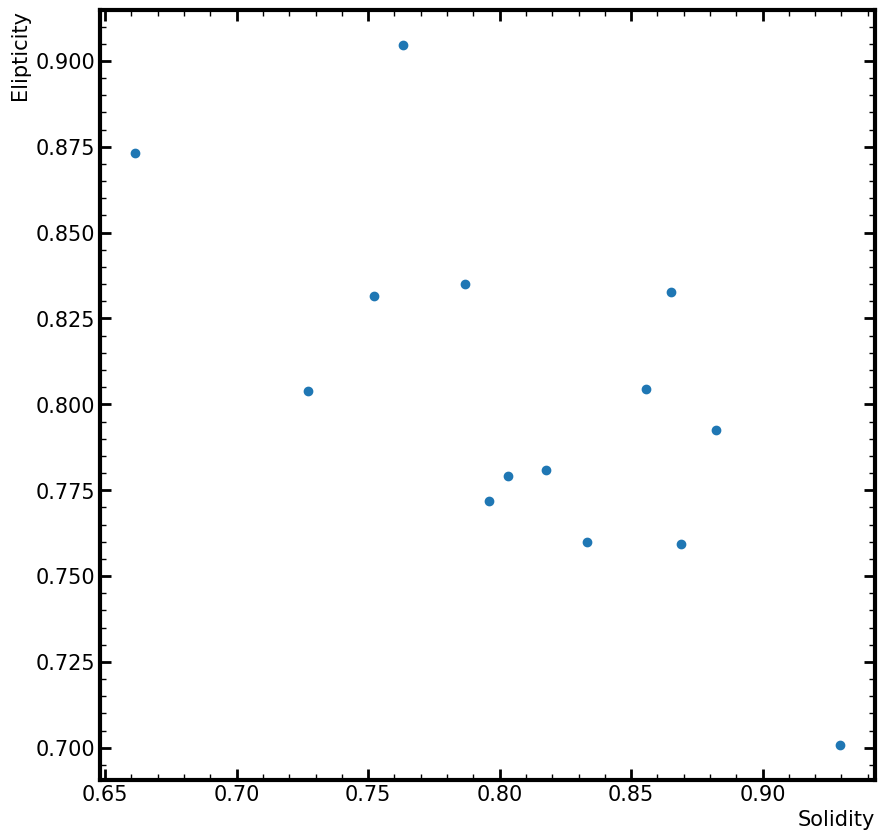

In [14]:
fig, axs = plt.subplots(ncols = 1, nrows = 1, figsize=(10,10))
axs.scatter(list_elip, list_soli)
axs.set_xlabel("Solidity")
axs.set_ylabel("Elipticity")
plt.show()